## Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from matplotlib.colors import ListedColormap
from mlxtend.plotting import plot_decision_regions
from scipy.stats import median_abs_deviation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

# Нейросеть

import keras
from tensorflow.keras import Sequential
from keras.layers import *



import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Загрузка данных

In [ ]:
composite_1 = pd.read_excel('/content/X_bp.xlsx')
composite_2 = pd.read_excel('/content/X_nup.xlsx')

In [ ]:
composite_1

,Unnamed: 0,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2"
0,0,1.857143,2030.000000,738.736842,30.000000,22.267857,100.000000,210.000000,70.000000,3000.000000,220.000000
1,1,1.857143,2030.000000,738.736842,50.000000,23.750000,284.615385,210.000000,70.000000,3000.000000,220.000000
2,2,1.857143,2030.000000,738.736842,49.900000,33.000000,284.615385,210.000000,70.000000,3000.000000,220.000000
3,3,1.857143,2030.000000,738.736842,129.000000,21.250000,300.000000,210.000000,70.000000,3000.000000,220.000000
4,4,2.771331,2030.000000,753.000000,111.860000,22.267857,284.615385,210.000000,70.000000,3000.000000,220.000000
...,...,...,...,...,...,...,...,...,...,...,...
1018,1018,2.271346,1952.087902,912.855545,86.992183,20.123249,324.774576,209.198700,73.090961,2387.292495,125.007669
1019,1019,3.444022,2050.089171,444.732634,145.981978,19.599769,254.215401,350.660830,72.920827,2360.392784,117.730099
1020,1020,3.280604,1972.372865,416.836524,110.533477,23.957502,248.423047,740.142791,74.734344,2662.906040,236.606764
1021,1021,3.705351,2066.799773,741.475517,141.397963,19.246945,275.779840,641.468152,74.042708,2071.715856,197.126067


In [ ]:
composite_2

,Unnamed: 0,"Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,0,0,4.000000,57.000000
1,1,0,4.000000,60.000000
2,2,0,4.000000,70.000000
3,3,0,5.000000,47.000000
4,4,0,5.000000,57.000000
...,...,...,...,...
1035,1035,90,8.088111,47.759177
1036,1036,90,7.619138,66.931932
1037,1037,90,9.800926,72.858286
1038,1038,90,10.079859,65.519479


In [ ]:
# Объединение датасетов в один

composite = pd.merge(composite_1, composite_2, how = 'inner')

composite = composite.dropna()

In [ ]:
composite.head() # Выводим первые пять строк датасета

,Unnamed: 0,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,0,1.857143,2030.0,738.736842,30.00,22.267857,100.000000,210.0,70.0,3000.0,220.0,0,4.0,57.0
1,1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,60.0
2,2,1.857143,2030.0,738.736842,49.90,33.000000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,70.0
3,3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0,0,5.0,47.0
4,4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,57.0


In [ ]:
# Удаляем идентификатор

composite = composite.drop('Unnamed: 0', axis = 1)

composite.head()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,1.857143,2030.0,738.736842,30.00,22.267857,100.000000,210.0,70.0,3000.0,220.0,0,4.0,57.0
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,60.0
2,1.857143,2030.0,738.736842,49.90,33.000000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,70.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0,0,5.0,47.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,57.0


# EDA

In [ ]:
# Наличие колонок

composite.columns

Index(['Соотношение матрица-наполнитель', 'Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2',
       'Поверхностная плотность, г/м2', 'Модуль упругости при растяжении, ГПа',
       'Прочность при растяжении, МПа', 'Потребление смолы, г/м2',
       'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки'],
      dtype='object')

<Axes: xlabel='Соотношение матрица-наполнитель', ylabel='Count'>

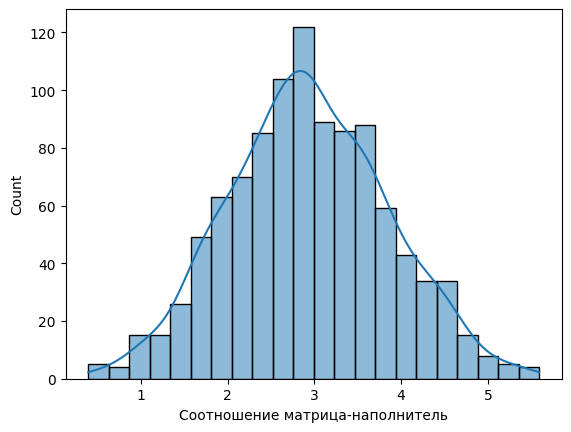

In [ ]:
# Распределение данных

sns.histplot(data = composite, x = 'Соотношение матрица-наполнитель', kde = True)

## Ящик с усами

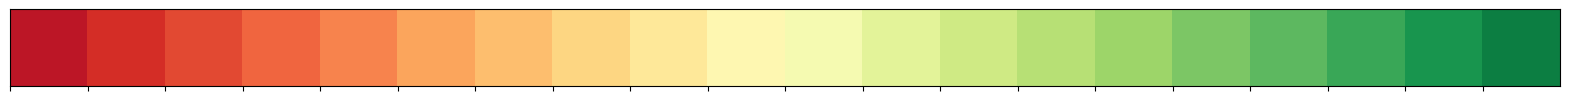

In [ ]:
# Создание цветовой палетки

selected_palette = sns.color_palette('RdYlGn', n_colors = 20)
sns.palplot(selected_palette)
plt.show()

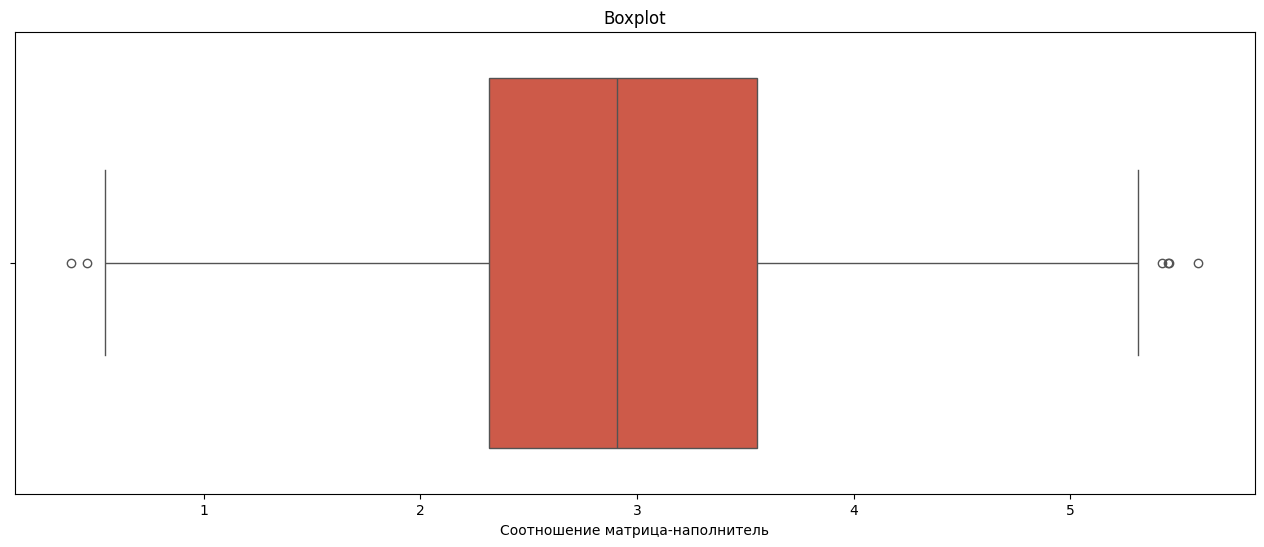

In [ ]:
plt.figure(figsize = (16, 6))
sns.boxplot(x = composite['Соотношение матрица-наполнитель'], color = selected_palette[2])

plt.title('Boxplot')
plt.xlabel('Соотношение матрица-наполнитель')

plt.show()

In [ ]:
# Поиск межквартильного размаха, медианы, усов, максимального и минимального значений

Me = composite['Прочность при растяжении, МПа'].quantile(0.5)
Q1 = composite['Прочность при растяжении, МПа'].quantile(0.25)
Q3 = composite['Прочность при растяжении, МПа'].quantile(0.75)

IQR = Q3 - Q1

lower_bound_predict = Q1 - 1.5 * IQR
minimum = composite['Прочность при растяжении, МПа'].min()
lower_bound = max(minimum, lower_bound_predict)
upper_bound_predict = Q3 + 1.5 * IQR
maximum = composite['Прочность при растяжении, МПа'].max()
upper_bound = min(maximum, upper_bound_predict)


print(f"Расчетный нижний ус {lower_bound_predict}")
print(f"Минимум {minimum}")
print(f"Нижний ус {lower_bound}")

print(f"Расчетный верхний ус {upper_bound_predict}")
print(f"Верхний ус {upper_bound}")
print(f"Максимум {maximum}")

print(f"Медиана {Me}")
print(f"Первый квартиль {Q1}")
print(f"Третий квартиль {Q3}")
print(f"Межквартильный размах {IQR}")

Расчетный нижний ус 1188.8364417822172
Минимум 1036.85660535
Нижний ус 1188.8364417822172
Расчетный верхний ус 3714.2071255870374
Верхний ус 3714.2071255870374
Максимум 3848.43673187618
Медиана 2459.52452600309
Первый квартиль 2135.8504482090248
Третий квартиль 2767.19311916023
Межквартильный размах 631.342670951205


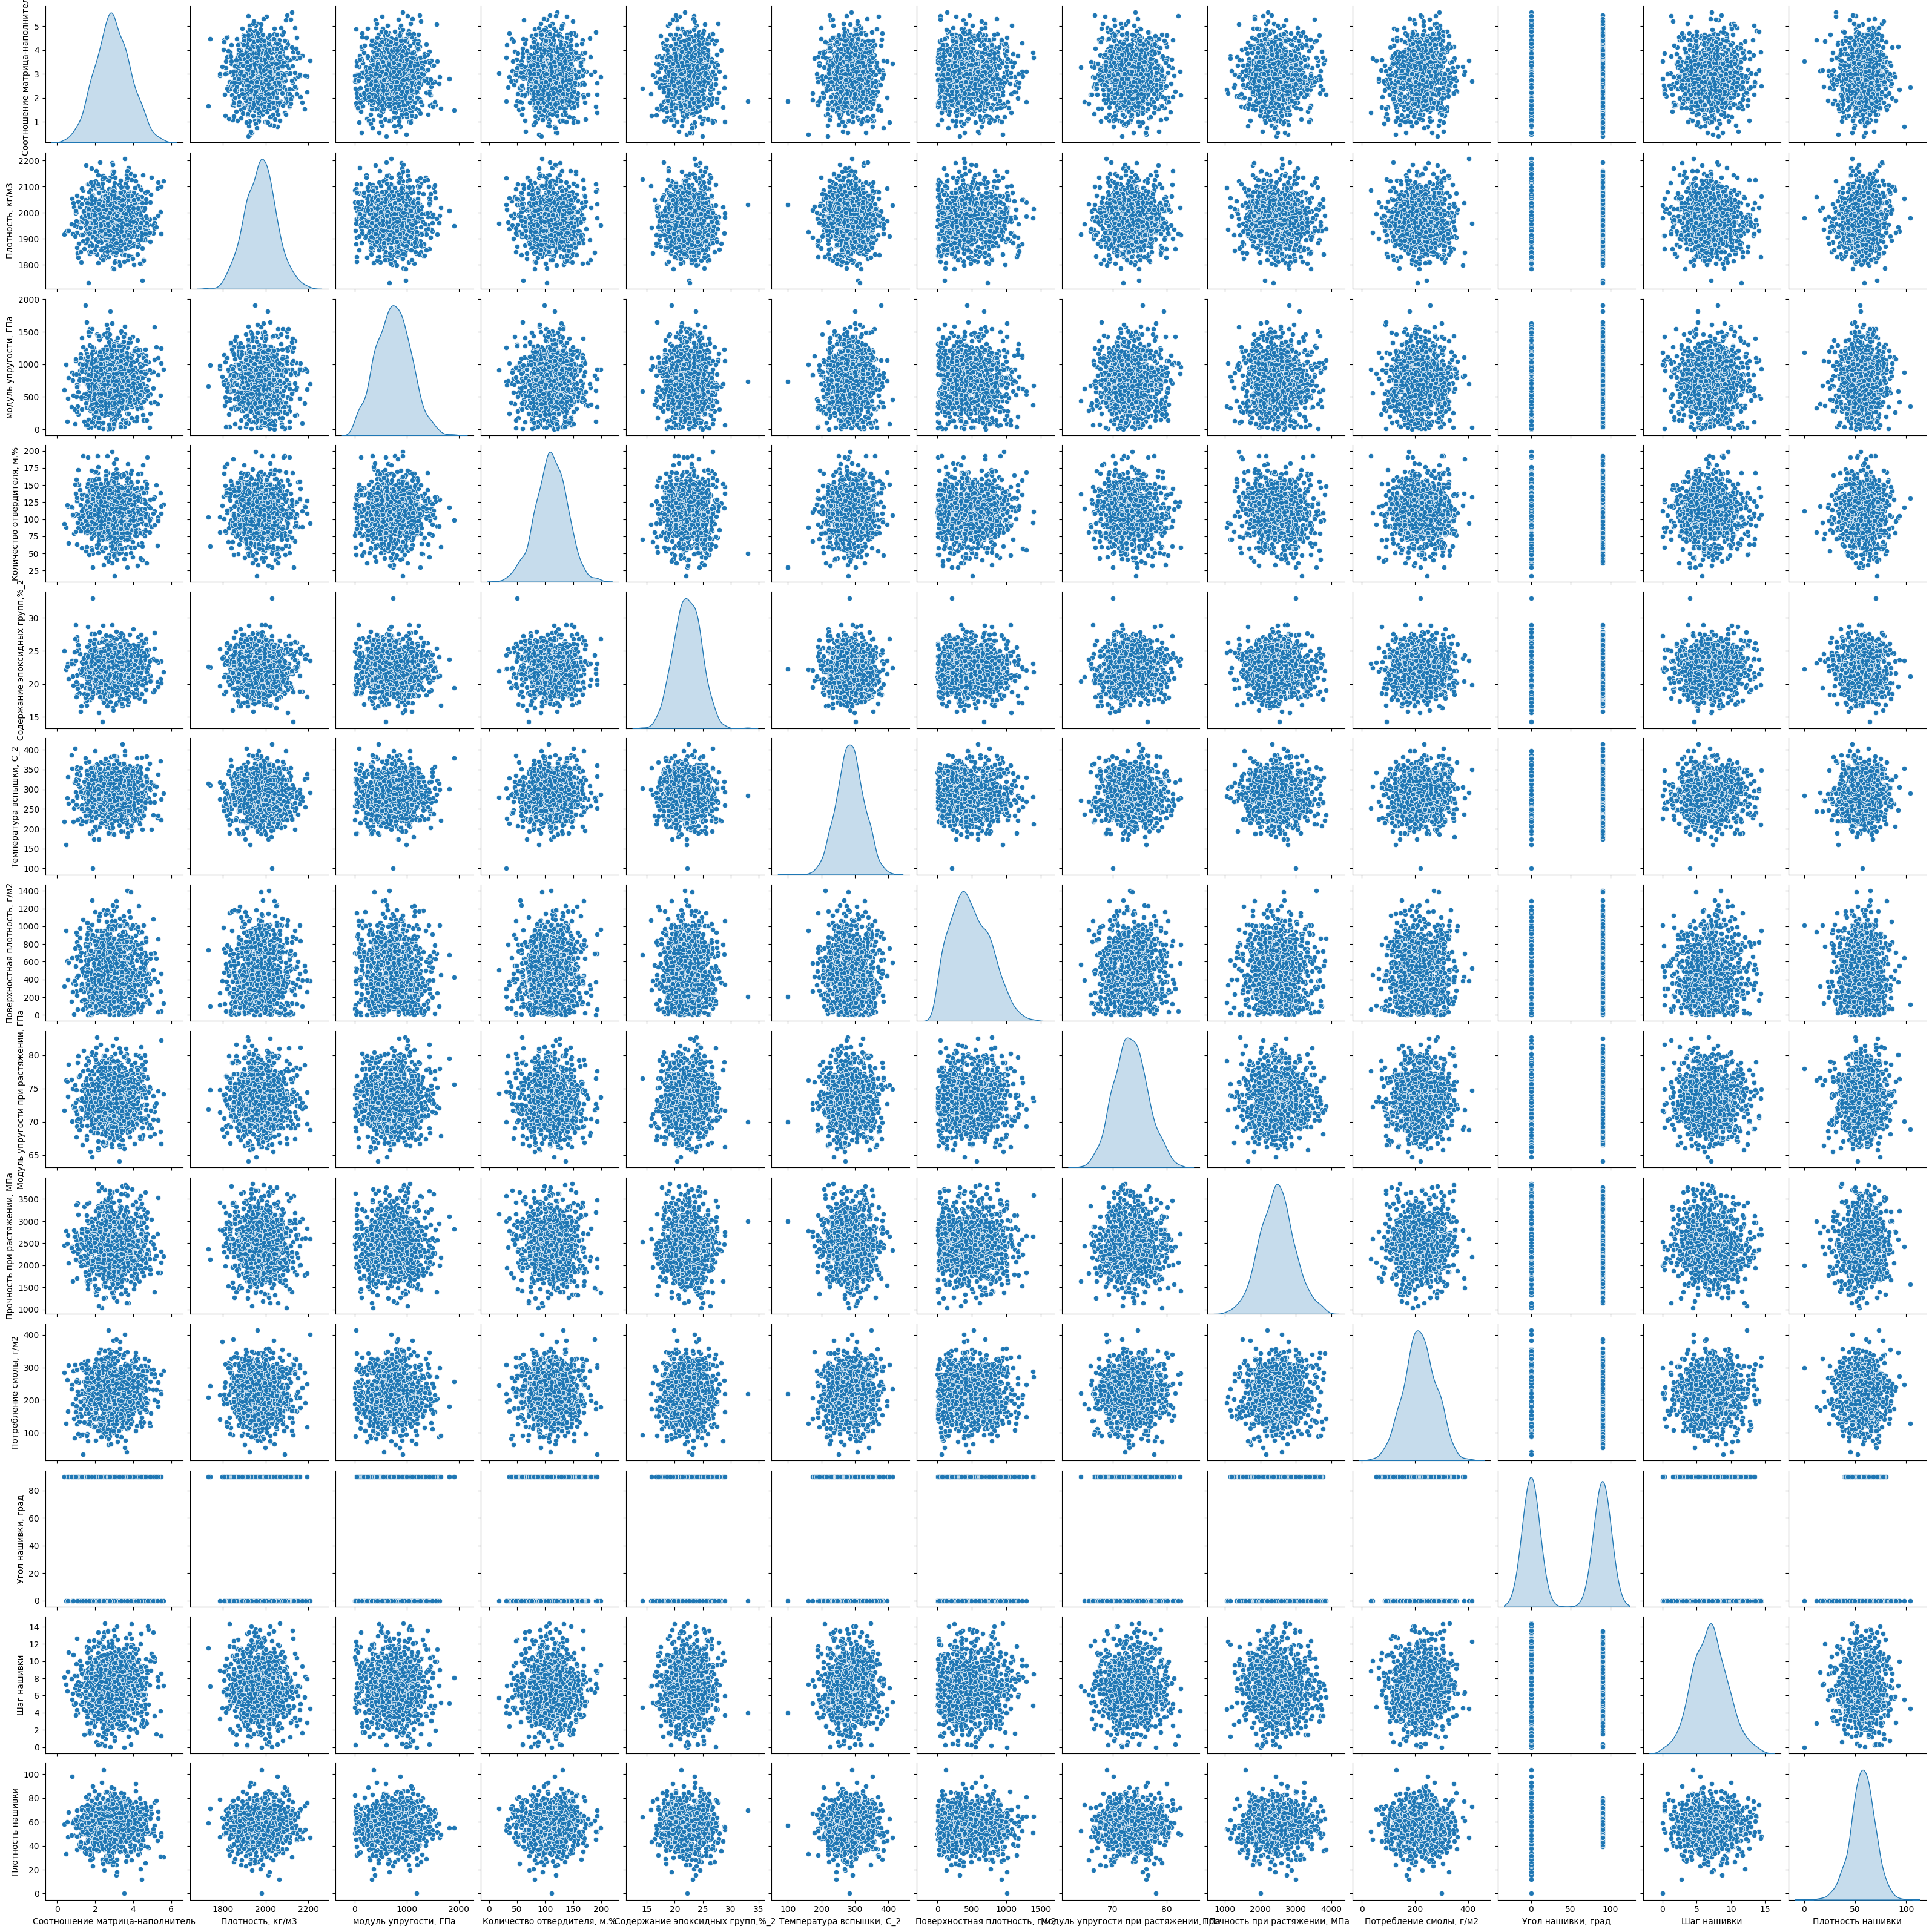

In [ ]:
# Попарные графики рассеяния точек

sns.pairplot(composite, diag_kind = 'kde')

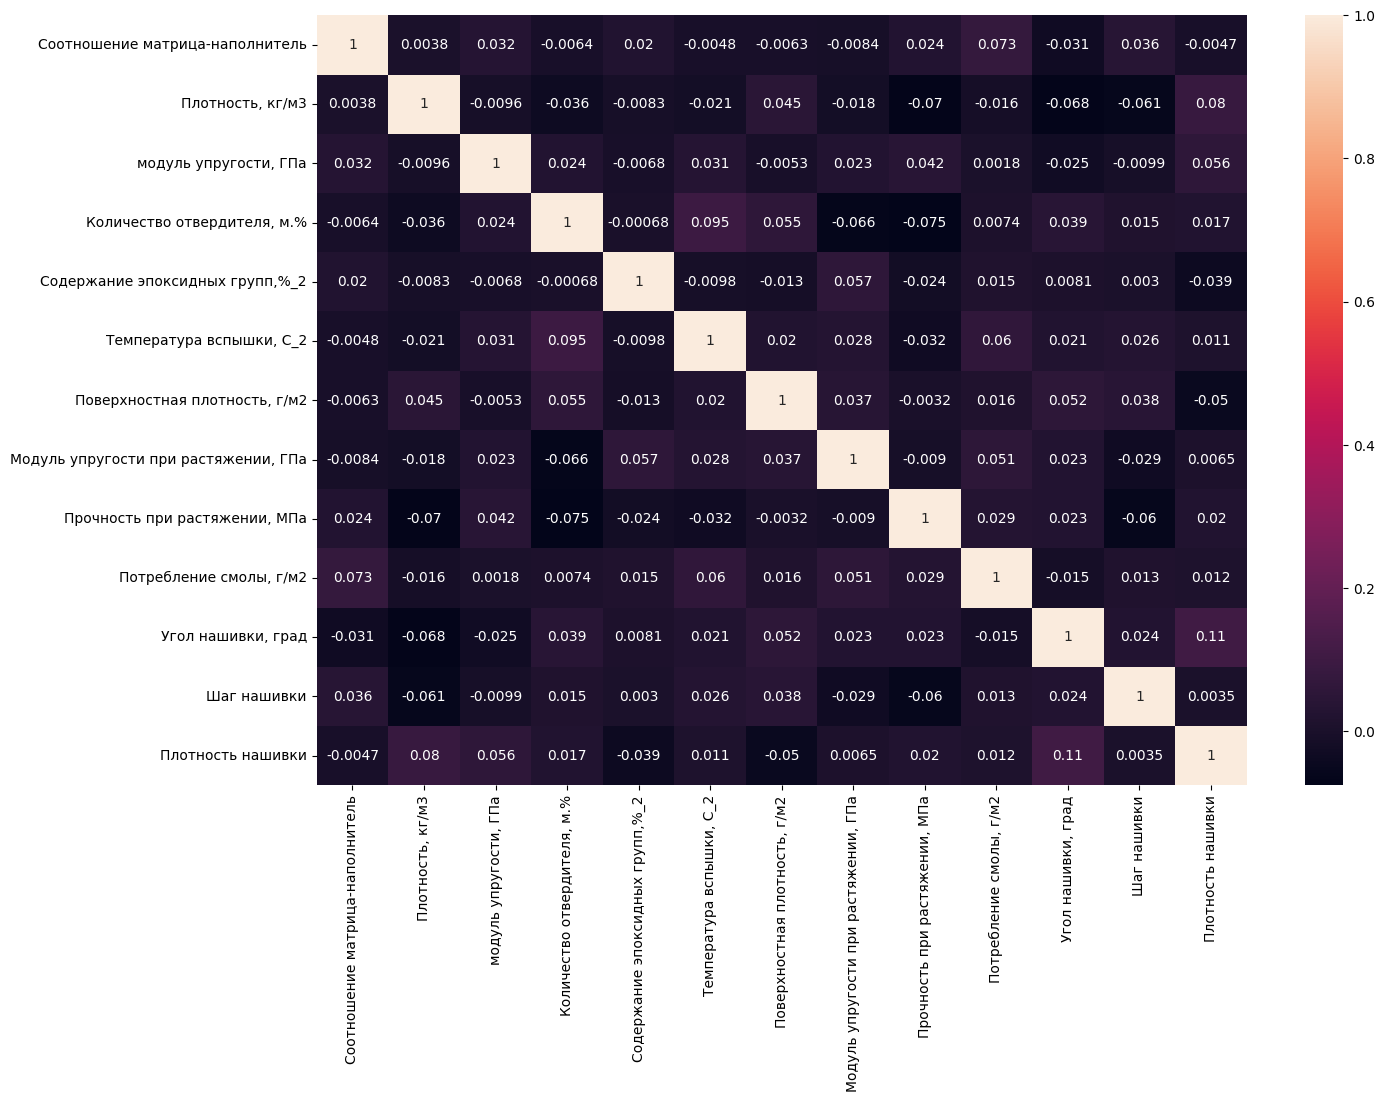

In [ ]:
plt.figure(figsize = (15, 10))
sns.heatmap(composite.corr(), annot = True)
plt.show()

In [ ]:
# Описание данных

composite.describe()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
count,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000
mean,2.930366,1975.734888,739.923233,110.570769,22.244390,285.882151,482.731833,73.328571,2466.922843,218.423144,44.252199,6.899222,57.153929
std,0.913222,73.729231,330.231581,28.295911,2.406301,40.943260,281.314690,3.118983,485.628006,59.735931,45.015793,2.563467,12.350969
min,0.389403,1731.764635,2.436909,17.740275,14.254985,100.000000,0.603740,64.054061,1036.856605,33.803026,0.000000,0.000000,0.000000
25%,2.317887,1924.155467,500.047452,92.443497,20.608034,259.066528,266.816645,71.245018,2135.850448,179.627520,0.000000,5.080033,49.799212
50%,2.906878,1977.621657,739.664328,110.564840,22.230744,285.896812,451.864365,73.268805,2459.524526,219.198882,0.000000,6.916144,57.341920
75%,3.552660,2021.374375,961.812526,129.730366,23.961934,313.002106,693.225017,75.356612,2767.193119,257.481724,90.000000,8.586293,64.944961
max,5.591742,2207.773481,1911.536477,198.953207,33.000000,413.273418,1399.542362,82.682051,3848.436732,414.590628,90.000000,14.440522,103.988901


In [ ]:
# Среднее значение

composite['Соотношение матрица-наполнитель'].mean()

np.float64(2.9303657734325483)

In [ ]:
# Медианное значение

composite['Соотношение матрица-наполнитель'].median()

2.90687765033521

In [ ]:
composite.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       1023 non-null   float64
 1   Плотность, кг/м3                      1023 non-null   float64
 2   модуль упругости, ГПа                 1023 non-null   float64
 3   Количество отвердителя, м.%           1023 non-null   float64
 4   Содержание эпоксидных групп,%_2       1023 non-null   float64
 5   Температура вспышки, С_2              1023 non-null   float64
 6   Поверхностная плотность, г/м2         1023 non-null   float64
 7   Модуль упругости при растяжении, ГПа  1023 non-null   float64
 8   Прочность при растяжении, МПа         1023 non-null   float64
 9   Потребление смолы, г/м2               1023 non-null   float64
 10  Угол нашивки, град                    1023 non-null   int64  
 11  Шаг нашивки      

In [ ]:
# Анализ и исключение выбросов

# Вычисляем медианное абсолютное отклонение (MAD)
MAD = median_abs_deviation(composite['Соотношение матрица-наполнитель'], scale = 'normal')

# Вычисляем Z-score
composite['Соотношение матрица-наполнитель_z_score'] = (composite['Соотношение матрица-наполнитель'] - composite['Соотношение матрица-наполнитель'].median()) / MAD

composite_z_score = pd.DataFrame(composite[['Соотношение матрица-наполнитель', 'Соотношение матрица-наполнитель_z_score']].head())
composite_z_score

,Соотношение матрица-наполнитель,Соотношение матрица-наполнитель_z_score
0,1.857143,-1.124743
1,1.857143,-1.124743
2,1.857143,-1.124743
3,1.857143,-1.124743
4,2.771331,-0.145232


In [ ]:
# Фильтрация строк, где z-score >=3 или <=3
outliers = composite[(composite['Соотношение матрица-наполнитель_z_score'] >=3) | (composite['Соотношение матрица-наполнитель_z_score'] <=-3)]

outliers = outliers[['Соотношение матрица-наполнитель', 'Соотношение матрица-наполнитель_z_score']]
outliers

,Соотношение матрица-наполнитель,Соотношение матрица-наполнитель_z_score


In [ ]:
# Наличие пропусков

composite.isnull().sum()

,0
Соотношение матрица-наполнитель,0
"Плотность, кг/м3",0
"модуль упругости, ГПа",0
"Количество отвердителя, м.%",0
"Содержание эпоксидных групп,%_2",0
"Температура вспышки, С_2",0
"Поверхностная плотность, г/м2",0
"Модуль упругости при растяжении, ГПа",0
"Прочность при растяжении, МПа",0
"Потребление смолы, г/м2",0


In [ ]:
composite.isnull().sum().sum()

np.int64(0)

In [ ]:
# Количество значений

composite.size

14322

In [ ]:
# Количество строк и столбцов

composite.shape

(1023, 14)

In [ ]:
composite.shape[0]

1023

In [ ]:
composite.shape[1]

14

In [ ]:
composite.isnull().sum().sum()

np.int64(0)

In [ ]:
# Процент отсутствующих значений
total_fields = composite.size
missing_values_count = composite.isnull().sum().sum()

missing_values_percentage = (missing_values_count / total_fields) * 100
print(f'Процент отсутствующих значений: {missing_values_percentage: .2f}%')

Процент отсутствующих значений:  0.00%


# Предобработка данных

In [ ]:
composite

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки,Соотношение матрица-наполнитель_z_score
0,1.857143,2030.000000,738.736842,30.000000,22.267857,100.000000,210.000000,70.000000,3000.000000,220.000000,0,4.000000,57.000000,-1.124743
1,1.857143,2030.000000,738.736842,50.000000,23.750000,284.615385,210.000000,70.000000,3000.000000,220.000000,0,4.000000,60.000000,-1.124743
2,1.857143,2030.000000,738.736842,49.900000,33.000000,284.615385,210.000000,70.000000,3000.000000,220.000000,0,4.000000,70.000000,-1.124743
3,1.857143,2030.000000,738.736842,129.000000,21.250000,300.000000,210.000000,70.000000,3000.000000,220.000000,0,5.000000,47.000000,-1.124743
4,2.771331,2030.000000,753.000000,111.860000,22.267857,284.615385,210.000000,70.000000,3000.000000,220.000000,0,5.000000,57.000000,-0.145232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,2.271346,1952.087902,912.855545,86.992183,20.123249,324.774576,209.198700,73.090961,2387.292495,125.007669,90,9.076380,47.019770,-0.680943
1019,3.444022,2050.089171,444.732634,145.981978,19.599769,254.215401,350.660830,72.920827,2360.392784,117.730099,90,10.565614,53.750790,0.575526
1020,3.280604,1972.372865,416.836524,110.533477,23.957502,248.423047,740.142791,74.734344,2662.906040,236.606764,90,4.161154,67.629684,0.400431
1021,3.705351,2066.799773,741.475517,141.397963,19.246945,275.779840,641.468152,74.042708,2071.715856,197.126067,90,6.313201,58.261074,0.855528


## Удаление шумов

In [ ]:
# Удаляем ненужные столбцы

composite = composite.drop(['Температура вспышки, С_2', 'Поверхностная плотность, г/м2', 'Потребление смолы, г/м2', 'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки', 'Соотношение матрица-наполнитель_z_score'], axis = 1)
composite

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа"
0,1.857143,2030.000000,738.736842,30.000000,22.267857,70.000000,3000.000000
1,1.857143,2030.000000,738.736842,50.000000,23.750000,70.000000,3000.000000
2,1.857143,2030.000000,738.736842,49.900000,33.000000,70.000000,3000.000000
3,1.857143,2030.000000,738.736842,129.000000,21.250000,70.000000,3000.000000
4,2.771331,2030.000000,753.000000,111.860000,22.267857,70.000000,3000.000000
...,...,...,...,...,...,...,...
1018,2.271346,1952.087902,912.855545,86.992183,20.123249,73.090961,2387.292495
1019,3.444022,2050.089171,444.732634,145.981978,19.599769,72.920827,2360.392784
1020,3.280604,1972.372865,416.836524,110.533477,23.957502,74.734344,2662.906040
1021,3.705351,2066.799773,741.475517,141.397963,19.246945,74.042708,2071.715856


In [ ]:
# Данные нормализованы, следовательно, проводим стандартизацию данных

std_scaler = StandardScaler()
composite_std = std_scaler.fit_transform(np.array(composite))

In [ ]:
composite_std[:1]

array([[-1.17577935,  0.73636539, -0.00359436, -2.84882775,  0.00975733,
        -1.06771965,  1.09824369]])

In [ ]:
composite_std_df = pd.DataFrame(data = composite_std, columns = ['Соотношение матрица-наполнитель',
                                                                 'Плотность, кг/м3',	'модуль упругости, ГПа',
                                                                 'Количество отвердителя, м.%',	'Содержание эпоксидных групп,%_2',
                                                                 'Модуль упругости при растяжении, ГПа',	'Прочность при растяжении, МПа'])

composite_std_df

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа"
0,-1.175779,0.736365,-0.003594,-2.848828,0.009757,-1.067720,1.098244
1,-1.175779,0.736365,-0.003594,-2.141666,0.626001,-1.067720,1.098244
2,-1.175779,0.736365,-0.003594,-2.145202,4.471955,-1.067720,1.098244
3,-1.175779,0.736365,-0.003594,0.651622,-0.413446,-1.067720,1.098244
4,-0.174232,0.736365,0.039618,0.045585,0.009757,-1.067720,1.098244
...,...,...,...,...,...,...,...
1018,-0.721995,-0.320884,0.523926,-0.833694,-0.881925,-0.076219,-0.164054
1019,0.562741,1.008971,-0.894327,1.252072,-1.099577,-0.130794,-0.219473
1020,0.383707,-0.045622,-0.978843,-0.001319,0.712276,0.450935,0.403764
1021,0.849043,1.235730,0.004703,1.089990,-1.246274,0.229077,-0.814204


In [ ]:
composite_std_df.describe()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа"
count,1.023000e+03,1.023000e+03,1.023000e+03,1.023000e+03,1.023000e+03,1.023000e+03,1.023000e+03
mean,-2.170524e-17,8.612639e-16,3.229740e-16,-6.424751e-17,-5.035616e-17,-1.093944e-16,7.779158e-16
std,1.000489e+00,1.000489e+00,1.000489e+00,1.000489e+00,1.000489e+00,1.000489e+00,1.000489e+00
min,-2.783776e+00,-3.310622e+00,-2.234332e+00,-3.282308e+00,-3.321825e+00,-2.975023e+00,-2.946217e+00
25%,-6.710072e-01,-6.999212e-01,-7.267418e-01,-6.409455e-01,-6.803619e-01,-6.683499e-01,-6.820742e-01
50%,-2.573263e-02,2.560303e-02,-7.843941e-04,-2.096293e-04,-5.673631e-03,-1.917160e-02,-1.524199e-02
75%,6.817601e-01,6.193176e-01,6.722489e-01,6.774466e-01,7.141185e-01,6.505431e-01,6.186158e-01
max,2.915695e+00,3.148712e+00,3.549589e+00,3.125033e+00,4.471955e+00,3.000355e+00,2.846190e+00


<Axes: xlabel='Соотношение матрица-наполнитель', ylabel='Count'>

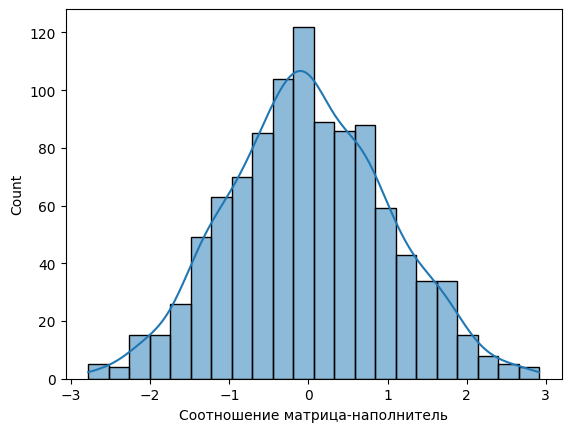

In [ ]:
# Распределение данных после стандартизации

sns.histplot(data = composite_std_df, x = 'Соотношение матрица-наполнитель', kde = True)

In [ ]:
# Сбалансированность

composite['Соотношение матрица-наполнитель'].value_counts()

,count
Соотношение матрица-наполнитель,
1.857143,4
3.557018,2
3.532338,2
2.919678,2
2.877358,2
...,...
2.908835,1
2.661267,1
3.324730,1


# Обучение и тестирование моделей

## Выделяем целевую переменную, делим данные на тестовую и обучабщую выборки

In [ ]:
X = composite.drop(['Соотношение матрица-наполнитель'], axis = 1)

y = composite['Соотношение матрица-наполнитель']

In [ ]:
X.shape, y.shape

((1023, 6), (1023,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
X_train.shape, y_train.shape

((716, 6), (716,))

In [ ]:
X_test.shape, y_test.shape

((307, 6), (307,))

In [ ]:
X = np.array(X)
X

array([[2030.        ,  738.73684211,   30.        ,   22.26785714,
          70.        , 3000.        ],
       [2030.        ,  738.73684211,   50.        ,   23.75      ,
          70.        , 3000.        ],
       [2030.        ,  738.73684211,   49.9       ,   33.        ,
          70.        , 3000.        ],
       ...,
       [1972.37286519,  416.83652353,  110.53347744,   23.95750159,
          74.7343437 , 2662.90603955],
       [2066.7997727 ,  741.47551674,  141.39796283,   19.24694474,
          74.04270842, 2071.71585567],
       [1890.413468  ,  417.31623197,  129.1834163 ,   27.47476302,
          74.309704  , 2856.32893217]])

In [ ]:
y = np.array(y)
y

array([1.85714286, 1.85714286, 1.85714286, ..., 3.28060448, 3.70535121,
       3.80802004])

In [ ]:
X_train = np.array(X_train)
X_test = np.array(X_test)

print(X_train)
print(X_test)

[[1862.67979248  341.67213227   75.06860003   25.95684243   73.0069352
  1399.11855514]
 [2006.13022947  950.61900625  154.66879974   24.18083223   69.21514387
  1337.74831683]
 [1946.47305421 1008.41590169  151.68492065   23.26775594   72.76297582
  2309.23374646]
 ...
 [1852.62244651  810.25022549  119.34425612   21.18937109   72.55881212
  2479.14974535]
 [2005.52525169 1065.57987688  138.13719783   18.29539847   70.6438996
  1703.06254612]
 [1881.61648733  663.33292063  123.50616687   28.32496802   71.8146156
  2323.71217705]]
[[1962.76495619  673.26374884   73.78095094   18.80074553   77.18080467
  2572.15578641]
 [1948.87861639  719.2465381    97.87478219   21.37626028   77.17120942
  2414.50736246]
 [1980.82378781  459.04706974   81.16253509   21.7873578    73.78982081
  2219.14260497]
 ...
 [1959.77963926   26.8269998   132.03195176   19.86879704   74.65915915
  2188.74447263]
 [1920.08559426  529.88706806  126.0539729    25.40392528   75.90215252
  2325.46498687]
 [2010.795406

In [ ]:
y_train = np.array(y_train)
y_test = np.array(y_test)

print(y_train)
print(y_test)

[3.57878397 2.9277966  2.27988647 3.01634337 2.03034004 2.36519348
 4.41513579 5.21044244 2.89547658 4.25097788 3.24158592 2.56147541
 3.63873982 3.64973882 3.99100288 3.58141044 3.12208927 3.29906254
 2.19674002 4.27532534 3.3076966  3.35568979 3.22843457 3.53734581
 1.98330137 2.16575633 3.28060448 2.16206654 2.926824   2.17943482
 2.19556801 2.14719452 3.55165436 2.89683591 3.26752297 3.62740512
 2.42479826 1.19053821 3.36950377 1.7446252  1.19352958 2.93667364
 3.95397838 3.35394515 1.59528458 3.27388807 2.54747914 2.7915043
 1.85714286 3.57278951 3.24653919 2.69248694 1.8572915  2.26652786
 2.93804285 2.43594631 3.44170558 2.92790509 3.63869887 5.12036848
 3.64575859 3.28135988 2.14361668 2.26318584 3.05995937 2.98721347
 2.79355698 1.09320812 3.12002168 1.81968256 2.75701625 2.6153093
 2.89129632 2.99512475 4.87425436 2.59468568 2.57175802 3.02122409
 2.27103246 2.84725922 2.67845916 2.70955409 2.66433264 2.34818546
 2.68378418 4.04142593 4.08817422 4.11413401 4.14830105 0.790499

## Нейросеть

In [ ]:
# Создаём архитектуру нейронной сети

model = Sequential()
model.add(Input((6,)))
model.add(Dense(12, activation = 'sigmoid'))
model.add(Dense(1, activation = 'relu'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss = 'mse', optimizer = keras.optimizers.Adam(0.001))

In [ ]:
history = model.fit(X_train,
                    y_train,
                    validation_split=0.15,
                    callbacks=[keras.callbacks.EarlyStopping(min_delta=0.0001,
                                                             patience=10,
                                                             verbose=1,
                                                             restore_best_weights=True)],
                    epochs=2000,
                    verbose=1)

Epoch 1/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.2124 - val_loss: 4.4623
Epoch 2/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.7912 - val_loss: 4.0375
Epoch 3/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.1137 - val_loss: 3.6957
Epoch 4/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9771 - val_loss: 3.3302
Epoch 5/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5071 - val_loss: 3.0258
Epoch 6/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0553 - val_loss: 2.7794
Epoch 7/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8754 - val_loss: 2.5361
Epoch 8/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5740 - val_loss: 2.2955
Epoch 9/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3208 - val_loss: 2.0473
Epoch 10/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1228 - val_loss: 1.7875
Epoch 11/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9302 - val_loss: 1.6153
Epoch 12/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/ste

In [ ]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

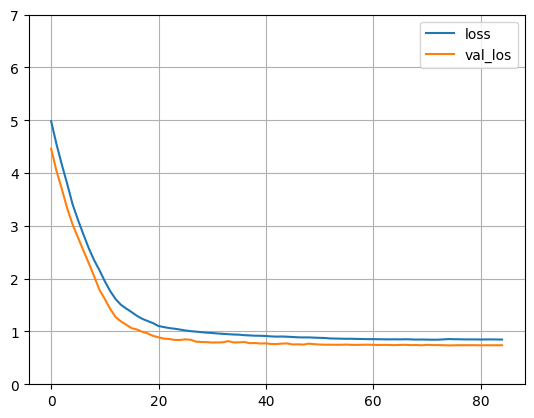

In [ ]:
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['val_loss'], label = 'val_los')
plt.ylim([0, 7])
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [ ]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
MAPE = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(MAE)
print(MSE)
print(RMSE)
print(MAPE)
print(r2)

0.7662165526444755
0.8869328426139653
0.941771120078528
0.3194249802740321
-0.03476185605379056
